# Second Homework: Network Optimization and Non-linear Models
**Optimization and Analytics**

Carla Aranda - 100523031, Marina Juzgado - 100523023

## a) Network Optimization Problem
### Summary
"Azure Paradise Resort" is a luxury resort located on a private island. The resort features 20 exclusive bungalows spread across the jungle and coastline, far from the central facilities. 
Every morning, the resort offers a gourmet breakfast service that is prepared in the Central Kitchen and delivered directly to each bungalow, where meals are ordered in function of the number of guests. Until now, this service has been using motorbikes, but the noise they produce and the inconvenience of someone showing up in the bungalow each morning negatively affect the experience of the guests. Moreover, motorbikes generate a carbon footprint and higher maintenance costs than an electric alternative. To improve privacy, comfort, and efficiency, the management has decided to replace the motorbikes with a set of autonomous delivery drones.

Each drone runs on a battery with a limited distance range, which restricts its autonomy. The resort has available 5 drones with 15 kilometers of autonomy, to deliver a maximum amount of 15 breakfasts each. The goal is to design an efficient delivery strategy that assigns routes to the drones in such a way that every bungalow is visited, the battery and capacity constraints are respected, and the overall travel distance is minimized.

To ensure all guests receive their breakfast hot and simultaneously, the problem is modeled as a Capacitated Vehicle Routing Problem (CVRP) where the set of drones is dispatched in a synchronized batch at 08:30 AM from the Central Kitchen.

The island has an approximate surface of 10 km², over which the bungalows are distributed and the Central Kitchen is located at the center. In the following code chunks we display the distance matrix and a map of the island.

In [1]:
import numpy as np
from scipy.spatial import distance_matrix
np.random.seed(123)

n = 21  # 20 bungalows + Central Kitchen

# Map definition (10x10 km)
coords = np.random.rand(n, 2) * 10000 
coords[0] = [5000, 5000] # Central Kitchen at the center

# Calculate distance matrix and convert to integer 
dist_matrix = distance_matrix(coords, coords)
cost = np.round(dist_matrix).astype(int)

# Distance matrix display
print("Distance matrix in meters:")
print(cost)

Distance matrix in meters:
[[   0 2779 2325 5151 1096 2776 4446 2589 4540  448 3744 2504 2843 3049
  2444 4132  694 2019 4002 4442 4039]
 [2779    0 5090 7656 2998 2124 5353 2533 3785 3053 5049 5012 5457 3501
  1040 1789 2120 3110 3960 7190 5895]
 [2325 5090    0 3698 2405 4850 4593 4500 5913 2171 4347 1880 1002 4073
  4738 6275 2971 3139 5542 2381 3220]
 [5151 7656 3698    0 5792 6391 8275 5851 9469 4746 3835 2667 4446 7691
  6892 9235 5822 6684 5923 1866 6718]
 [1096 2998 2405 5792    0 3640 3351 3557 3688 1486 4824 3274 2512 2026
  3035 3910 1132  970 5042 4760 3113]
 [2776 2124 4850 6391 3640    0 6761  556 5764 2727 3151 3991 5557 5011
  1098 3876 2512 4249 1842 6425 6746]
 [4446 5353 4593 8275 3351 6761    0 6795 2810 4812 8137 6211 3872 1852
  5894 5098 4341 2529 8338 6717 1936]
 [2589 2533 4500 5851 3557  556 6795    0 6024 2456 2613 3502 5268 5110
  1495 4315 2465 4266 1580 5950 6621]
 [4540 3785 5913 9469 3688 5764 2810 6024    0 4988 8115 6953 5597 1869
  4689 2736 4037 2792

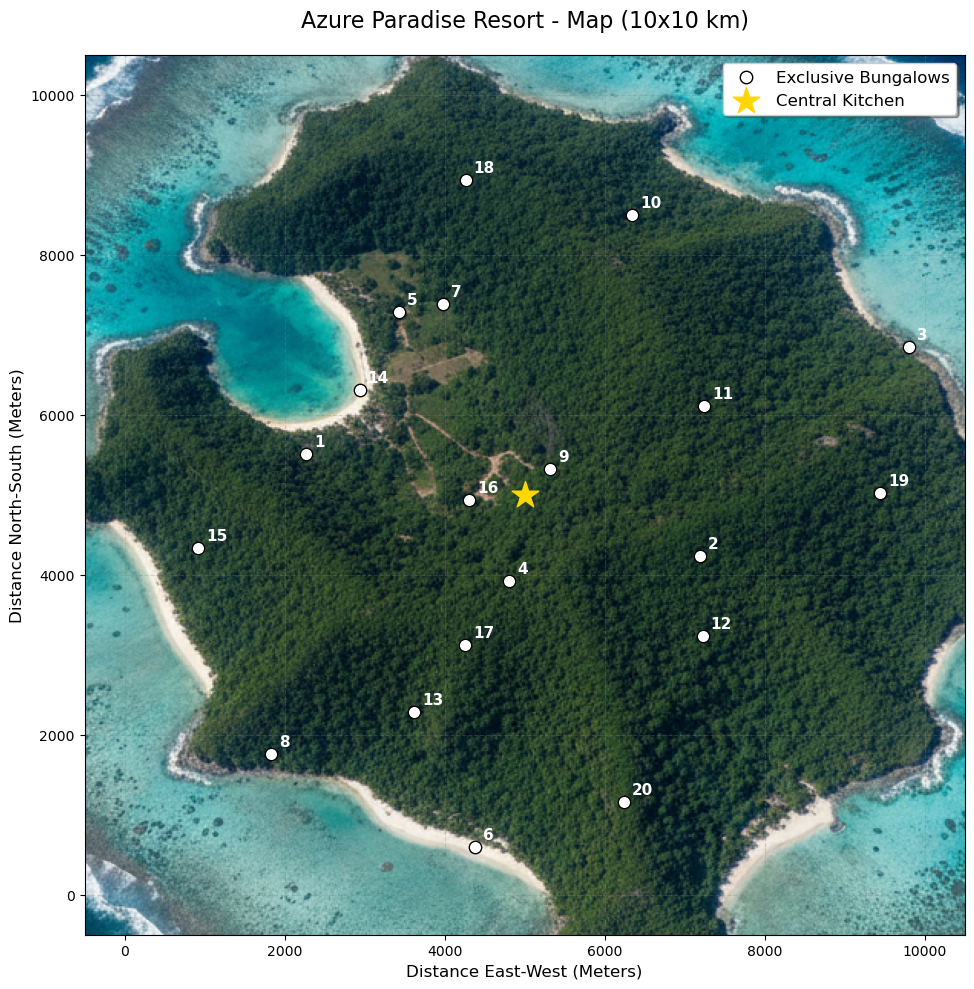

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10)) 
plt.imshow(plt.imread('map.png'), extent=[-500, 10500, -500, 10500], zorder=0)

plt.scatter(coords[1:, 0], coords[1:, 1], 
            c='white', s=80, edgecolors='black', zorder=2, label='Exclusive Bungalows')

plt.scatter(coords[0, 0], coords[0, 1], 
            c='gold', marker='*', s=400, zorder=3, label='Central Kitchen')

for i in range(1, n):
    plt.text(coords[i, 0] + 100, coords[i, 1] + 100, f"{i}", c='white', fontsize=11, weight='bold')

plt.title("Azure Paradise Resort - Map (10x10 km)", fontsize=16, pad=20)
plt.xlabel("Distance East-West (Meters)", fontsize=12)
plt.ylabel("Distance North-South (Meters)", fontsize=12)
plt.legend(loc='upper right', fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', color='gray', alpha=0.3, zorder=0)

plt.xlim(-500, 10500)
plt.ylim(-500, 10500)

plt.tight_layout()
plt.show()

### General formulation

### Sets
- $N$ = \{0, 1, ..., 20\}: Set of locations (index $i, j$)
  - 0 = Central Kitchen (Depot).
  - 1, ..., 20 = Guest Bungalows.
- $N^+$ = \{1, ..., 20\}: Set of customers (Bungalows only).

### Parameters
| Parameter | Description | Values |
|:-----------|:-------------|:-------|
|$c_{i,j}$ | Travel distance between locations (meters) | Calculated from map coordinates |
|$d_i$ | Daily breakfast demand per bungalow | Integers $\in [2, 4]$ ($d_0 = 0$) |
|$Q$ | Maximum capacity of a drone | 15 |
|$K$ | Number of available drones | 5 |
|$L_{max}$ | Maximum flight range per trip (meters) | 15000 |

### Decision variables
- $x_{i,j}$ = Binary variable equal to 1 if a drone travels from $i$ to $j$, 0 otherwise.
- $u_i$ = Continuous variable: Accumulated load of the drone after visiting node $i$.
- $w_i$ = Continuous variable: Accumulated distance traveled by the drone upon arrival at node $i$.

Total number of binary decision variables: $21 \times 20 = 420$.

### Objective
Minimizing the total distance traveled by the drones:
$$
\min \sum_{i \in N}\sum_{j \in N, i \neq j} c_{i,j} x_{i,j}
$$

### Constraints

#### 1. Demand satisfaction (Inflow)
Each bungalow must be visited exactly once to receive its breakfast:
$$
\sum_{i \in N, i \neq j} x_{i,j} = 1, \quad \forall j \in N^+
$$

#### 2. Flow conservation (Outflow)
After delivering to a bungalow, the drone must leave to another node:
$$
\sum_{j \in N, j \neq i} x_{i,j} = 1, \quad \forall i \in N^+
$$

#### 3. Central Kitchen (Depot) Constraints
Exactly $K$ drones leave the Central Kitchen and $K$ drones return:
$$
\sum_{j \in N^+} x_{0,j} = K
$$
$$
\sum_{i \in N^+} x_{i,0} = K
$$

#### 4. Capacity and Subtour Elimination
Ensures routes are connected and demand does not exceed capacity (MTZ logic):
$$
u_i - u_j + Q \cdot x_{i,j} \leq Q - d_j, \quad \forall i, j \in N^+, i \neq j
$$

#### 5. Load boundaries
The load variable must be at least the demand and cannot exceed capacity:
$$
d_i \leq u_i \leq Q, \quad \forall i \in N^+
$$

#### 6. Battery constraints (Accumulation & Limit)
We track the accumulated distance ($w_i$) along the route. This constraint correctly propagates distance accumulation due to flow conservation. Additionally, we ensure that the distance to reach node $i$ plus the return to the central kitchen does not exceed $L_{max}$:

$$
w_i + c_{i,j} - L_{max} \cdot (1 - x_{i,j}) \leq w_j, \quad \forall i \in N, j \in N^+, i \neq j
$$
$$
w_i + c_{i,0} \leq L_{max}, \quad \forall i \in N^+
$$

#### 7. Variable domains
Definition of binary and continuous variables:
$$
x_{i,j} \in \{0, 1\}, \quad \forall i,j \in N, i \neq j
$$
$$
u_i \geq 0, \quad \forall i \in N^+
$$
$$
w_0 = 0; \quad 0 \leq w_i \leq L_{max}, \quad \forall i \in N
$$

### Data Definition

In [3]:
import pyomo.environ as pyo
import numpy as np
from scipy.spatial import distance_matrix

n = 21  # 0 = Kitchen, 1-20 = Bungalows
N = list(range(n))
N_plus = list(range(1, n))

K_drones = 5     
Q_capacity = 15 
L_max = 15000      

# Demand: between 2 and 4 units per bungalow
np.random.seed(123)
demand_arr = np.random.randint(2, 5, size=n) 
demand_arr[0] = 0

# Convert numpy arrays to dictionaries for Pyomo
costs = {(i, j): cost[i, j] for i in N for j in N}
demand = {i: demand_arr[i] for i in N}

print(f"Total Demand: {sum(demand_arr)}")
print(f"Fleet Capacity: {K_drones * Q_capacity}")

Total Demand: 65
Fleet Capacity: 75


### Build the model

In [4]:
model = pyo.ConcreteModel()

# --- Sets ---
model.N = pyo.Set(initialize=N)
model.N_plus = pyo.Set(initialize=N_plus)

# --- Variables ---
# x[i,j]: Binary = 1 if drone travels i -> j
model.x = pyo.Var(model.N, model.N, domain=pyo.Binary)

# u[i]: Accumulated load after visiting i
model.u = pyo.Var(model.N, domain=pyo.NonNegativeReals)

# w[i]: Accumulated distance traveled upon arrival at i
model.w = pyo.Var(model.N, bounds=(0, L_max))

# --- Objective: Minimize total distance ---
def total_dist_rule(model):
    return sum(costs[i,j] * model.x[i,j] for i in model.N for j in model.N if i != j)
model.obj = pyo.Objective(rule=total_dist_rule, sense=pyo.minimize)

# --- Constraints ---
# 1. Demand satisfaction (Inflow)
def inflow_rule(model, j):
    return sum(model.x[i,j] for i in model.N if i != j) == 1
model.inflow = pyo.Constraint(model.N_plus, rule=inflow_rule)

# 2. Flow conservation (Outflow)
def outflow_rule(model, i):
    return sum(model.x[i,j] for j in model.N if i != j) == 1
model.outflow = pyo.Constraint(model.N_plus, rule=outflow_rule)

# 3. Central Kitchen Constraints
def depot_out_rule(model):
    return sum(model.x[0,j] for j in model.N_plus) == K_drones
model.depot_out = pyo.Constraint(rule=depot_out_rule)

def depot_in_rule(model):
    return sum(model.x[i,0] for i in model.N_plus) == K_drones
model.depot_in = pyo.Constraint(rule=depot_in_rule)

# 4. Capacity and Subtour Elimination (MTZ Load)
def capacity_mtz_rule(model, i, j):
    if i != j:
        return model.u[i] - model.u[j] + Q_capacity * model.x[i,j] <= Q_capacity - demand[j]
    return pyo.Constraint.Skip
model.capacity_mtz = pyo.Constraint(model.N_plus, model.N_plus, rule=capacity_mtz_rule)

# 5. Load boundaries
def load_bounds_rule(model, i):
    return pyo.inequality(demand[i], model.u[i], Q_capacity)
model.load_bounds = pyo.Constraint(model.N_plus, rule=load_bounds_rule)

# 6. Battery constraints
# 6a. Accumulation of distance
def distance_mtz_rule(model, i, j):
    if i != j:
        # w_i + cost_ij - L_max*(1-x_ij) <= w_j
        return model.w[i] + costs[i,j] - L_max * (1 - model.x[i,j]) <= model.w[j]
    return pyo.Constraint.Skip
model.distance_mtz = pyo.Constraint(model.N, model.N_plus, rule=distance_mtz_rule)

# 6b. Return to depot limit
def battery_limit_rule(model, i):
    return model.w[i] + costs[i,0] <= L_max
model.battery_limit = pyo.Constraint(model.N_plus, rule=battery_limit_rule)

# 7. Domain Initialization
# Fix w_0 = 0 
def depot_start_rule(model):
    return model.w[0] == 0
model.depot_start = pyo.Constraint(rule=depot_start_rule)

# Fix diagonals (no self-loops)
def no_self_loop(model, i):
    return model.x[i,i] == 0
model.no_self_loop = pyo.Constraint(model.N, rule=no_self_loop)

print("Model construction complete.")

Model construction complete.


### Solve the model


In [ ]:
from pyomo.environ import SolverFactory

# Create a solver
solver = SolverFactory('gurobi')

# Solve the model
result = solver.solve(model, tee=True)

if result.solver.termination_condition == pyo.TerminationCondition.optimal:
    r_idx = 1
    for s in N_plus:
        if pyo.value(model.x[0, s]) > 0.5: 
            curr, load, dist, path = s, demand[s], costs[0, s], f"0->{s}"
            
            while curr != 0:
                for j in N:
                    if j != curr and pyo.value(model.x[curr, j]) > 0.5:
                        dist += costs[curr, j]
                        path += f"->{j}"
                        if j != 0: load += demand[j]
                        curr = j
                        break
            
            print(f"Route {r_idx}: {path}  (Load: {load}/{Q_capacity} | Dist: {dist}m)")
            r_idx += 1


Read LP format model from file C:\Users\carla\AppData\Local\Temp\tmpt24e_twr.pyomo.lp
Reading time = 0.01 seconds
x1: 904 rows, 482 columns, 3262 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 11th Gen Intel(R) Core(TM) i5-1155G7 @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 904 rows, 482 columns and 3262 nonzeros
Model fingerprint: 0x7b81caf0
Variable types: 41 continuous, 441 integer (441 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+04]
  Objective range  [4e+02, 9e+03]
  Bounds range     [1e+00, 2e+04]
  RHS range        [1e+00, 1e+04]
Presolve removed 106 rows and 46 columns
Presolve time: 0.03s
Presolved: 798 rows, 436 columns, 6036 nonzeros
Variable types: 40 continuous, 396 integer (396 binary)

Root relaxation: objective 3.920120e+04, 127 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Curr

Visualize the optimal delivery routes found by the solver
| Route | Delivery sequence | Load | Distance |
| :---: | :--- | :---: | :---: |
| **1** | 0 → 1 → 15 → 8 → 13 → 4 → 0 | **15/15** | 12,295 m |
| **2** | 0 → 5 → 7 → 18 → 10 → 0 | 13/15 | 10,782 m |
| **3** | 0 → 9 → 14 → 16 → 0 | 9/15 | 5,660 m |
| **4** | 0 → 11 → 3 → 19 → 2 → 0 | 14/15 | 11,743 m |
| **5** | 0 → 17 → 6 → 20 → 12 → 0 | 14/15 | 11,622 m |
| **Total** | | **65/75** | **52,102 m** |

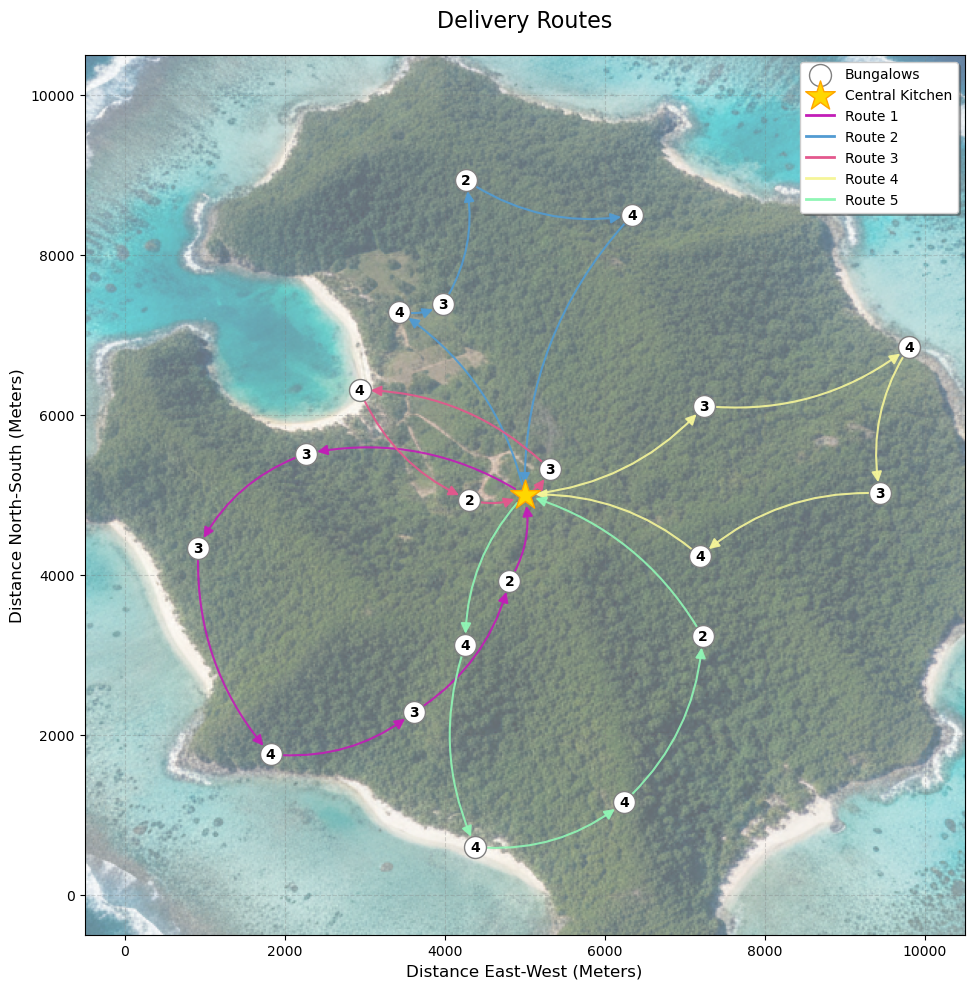

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.figure(figsize=(10, 10))
plt.imshow(plt.imread('map.png'), extent=[-500, 10500, -500, 10500], zorder=0, alpha=0.6)

plt.scatter(coords[1:, 0], coords[1:, 1], 
            c='white', s=250, edgecolors='gray', zorder=10, label='Bungalows')

plt.scatter(coords[0, 0], coords[0, 1], 
            c='gold', marker='*', s=500, edgecolors='orange', zorder=11, label='Central Kitchen')

for i in range(1, n):
    plt.text(coords[i, 0], coords[i, 1], str(demand[i]), 
             c='black', fontsize=10, weight='bold', ha='center', va='center', zorder=12)

colors = ["#c21db7", "#529bd2", "#e3588d", "#f5f599", "#90f6b5"]
ax = plt.gca()
route_idx = 0

for start_node in N_plus:
    if pyo.value(model.x[0, start_node]) > 0.5:
        current_node = 0
        next_node = start_node
        color = colors[route_idx % len(colors)]
        
        while True:
            p1 = coords[current_node]
            p2 = coords[next_node]
            arrow = patches.FancyArrowPatch((p1[0], p1[1]), (p2[0], p2[1]),
                connectionstyle="arc3,rad=0.2", color=color, arrowstyle='-|>', mutation_scale=15, 
                linewidth=1.5, alpha=0.9, zorder=5, shrinkA=8, shrinkB=8)
            ax.add_patch(arrow)
            current_node = next_node
            found_next = False
            if current_node != 0:
                for j in N:
                    if j != current_node and pyo.value(model.x[current_node, j]) > 0.5:
                        next_node = j
                        found_next = True
                        break
            
            if current_node == 0 or not found_next:
                break
        
        plt.plot([], [], color=color, linewidth=2, label=f'Route {route_idx+1}')
        route_idx += 1


plt.title(f"Delivery Routes", fontsize=16, pad=20)
plt.xlabel("Distance East-West (Meters)", fontsize=12)
plt.ylabel("Distance North-South (Meters)", fontsize=12)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle='--', color='gray', alpha=0.3, zorder=0)

plt.xlim(-500, 10500)
plt.ylim(-500, 10500)

plt.tight_layout()
plt.show()

### Interpretation of the solution
The most interesting feature of this solution is how well the algorithm made use of the space inside the drones. Instead of sending five drones that are half-empty, the system packed the breakfast in a smart way. It filled four of the drones almost to the top of their capacity, while leaving the drone of the route number 3 to deliver the remaining units. This is the best way to operate because it ensures that every flown kilometer is productive.

The algorithm intelligently assigned the heavy lifting to four drones, while keeping the route 3 drone as a support unit. This drone takes care of the bungalows that are too close to include in a trip that could be used more efficiently to reach the further bungalows. This prevents the long-distance drones from making inefficient detours to drop off just one or two meals.

Even though most drones are working almost to their maximum load, the solution is very safe. The longest route found is almost 3km below the maximum range of the battery, which gives a security margin in case that any problems could appear during the delivery. It ensures that if there is strong wind, or if a drone takes longer to land than expected, it will not run out of power mid-flight. 

Aside from the shorter support route, we have a balanced workload since the other four drones are flying very similar distances. This is great for maintenance, it means four of your five batteries will age at the same speed, making it easier to schedule repairs or replacements. 

Overall, this solution proves that 5 drones is the perfect size for the resort's needs. It meets the demand of every single guest in just a single delivery wave. It is a robust, cost-effective, and safe logistics plan.

## b) Non-linear Optimization Problem

### Summary

#### 1. Scenario

As a non-linear optimization problem for this section based on a realistic hypothetical scenario, we have modeled a delivery platform (similar to Uber Eats or Glovo) operating in a large city like Madrid. With a population of 3.3 million inhabitants, Madrid presents a high-frequency consumption market. However, delivery services are also extremely sensitive to operational failures.

The success of such a platform is not centered only on having a large database of restaurants; it must also create a perfect balance between supply and demand in real time, optimizing delivery times, prices, and resources.

While the previous exercise focused on logistics and routing, this section aims to optimize the economic and operational variables to maximize monthly profit. The goal is to ensure a stable demand without collapsing the network or losing revenue.

The market parameters established in this formulation are based on a city the size of a European capital:
- **Order potential (A):** 50,000 orders per month. Given the demographic density and the thousands of available restaurants, this is a realistic scale.
- **Service Level Agreement (SLA):** A maximum waiting time of 30 minutes, based on urban traffic conditions and competitive standards in the sector.

The business faces a dilemma of three competing forces that justify the use of non-linear optimization:

1. **Market Elasticity:** The commission is our primary revenue source but also the biggest barrier for partners. Restaurant margins are tight, and a significant raise in the commission rate ($c$) to cover operational costs causes demand to drop exponentially. Conversely, lowering the commission too much might saturate the platform, leading to delivery costs that exceed revenues.

2. **Logistics Barrier:** The size of the fleet is a critical decision variable. Too few delivery agents result in low fixed costs but infinite waiting times (system collapse). Too many agents represent significant fixed costs, especially considering labor regulations in Spain, which imply minimum salaries and specific working conditions.

3. **Complexity Costs:** Managing a fleet in a large city does not scale linearly. As the business hires more staff, the costs of coordination, technical support, insurance, and infrastructure grow quadratically ($n^2$). This term captures the "diseconomy of scale" that occurs when a logistics network becomes too dense to be manageable.


#### 2. General Objective

The fundamental objective is to design a systematic business strategy. We aim to maximize the **Total Monthly Profit** of the delivery platform by optimizing two key decision variables: the **commission rate ($c$)** and the **number of delivery agents ($n$)**.

Through non-linear optimization, we aim to transform the logistics of a large-scale delivery network into a precise operation. The model will determine the equilibrium point where demand, service quality, and operational costs are perfectly balanced.

### General formulation

#### 1. Variables and Parameters

##### 1.1. Decision Variables
| Variable | Description | Units | Range |
| :--- | :--- | :--- | :--- |
| $c$ | Commission rate charged to restaurants | % (decimal) | [0.10, 0.40] |
| $n$ | Number of active deliverymen | Integer | [10, 100] |

##### 1.2. Model Parameters
| Parameter | Description | Value |
| :--- | :--- | :--- |
| $A$ | Market potential | 50.000 |
| $k$ | Price sensitivity (how fast customers leave if comissions rise) | 4,5 |
| $T_{avg}$ | Average order price | 25 € |
| $W$ | Monthly salary/cost per deliveryman | 1200 € |
| $\mu$ | Deliveries per hour per deliveryman | 3 |
| $t_{max}$ | Max allowed average wait time | 30 min |
| $H$ | Total working hours per month | 160 h |



#### 2. Mathematical Formulation

##### 2.1. Objective Function
We maximize the **Profit Function** $f(c, n)$, which is the difference between revenue from commissions and operational costs.

$$Maximize \ Z = (D(c) \cdot T_{avg} \cdot c) - (n \cdot W + 0.1 \cdot n^2)$$

Where the **Demand Function** is non-linear. It is the relationship between the price (or comission in this case), in economy this is never linear and we use an exponential decay function that represents what is called as "Price Elasticity", as the comission $c$ increases, demand $D(c)$ drops quickly at first, it ensures the solver to find the right spot rather than just picking the highest price:
$$D(c) = A \cdot e^{-k \cdot c}$$

The term $0.1 \cdot n^2$ in the function we want to maximize represents the non-linear management overhead as the number of active deliverymen $n$ increases. As this number becomes larger, the cost of managing them (coordination, insurance, infrastructure, vehicles...) does not grow linearly, it grows quadratically because of the complexity of the network increases.

##### 2.2. Non-Linear Constraints
To ensure the model is non-trivial, we include a service quality constraint:

1. **Waiting Time Constraint (Non-Linear):** The average wait time must not exceed 30 minutes. This term is based on Queuing Theory. The term in the denominator represents the unused capacity, as the demand aproaches the maximum capacity of the deliveries, the waiting time converges to infinity. By setting the t_{max} we force the model to hire more deliverymen to prevent the system from collapsing.
$$\frac{1}{\mu \cdot n - \frac{D(c)}{160}} \leq t_{max}$$

2. **Boundary Constraints:** They are necessary as in real life cases, if comission is higher than a 40% there would be a massively loss of customers and restaurants. Moreover, the number of deliverymen must also be regulated with a minimum and a maximum rate.
$$0.10 \leq c \leq 0.40$$
$$10 \leq n \leq 100$$

##### 2.3. Model Robustness and Stability
To ensure the mathematical stability of the non-linear solver and the economic viability of the platform, we implement the following safety buffers:

1. **System Stability Condition:** The total service capacity must exceed the arrival rate of orders ($\mu \cdot n > \frac{D(c)}{160}$). This prevents the queuing model from reaching a mathematical singularity where waiting times tend to infinity, ensuring the solver stays within a numerically stable region.
2. **Economic Feasibility (Break-even):** Although implicit in the maximization of $Z$, this condition ensures that total commission revenue always covers the quadratic operational costs, guaranteeing that the platform does not operate at a loss.
3. **Market Integrity:** By capping the commission $c$ at 40%, we model the 'Market Churn' effect, acknowledging that excessive rates would lead to a total exit of restaurant partners and customers, even if the theoretical profit curve suggested otherwise.

### Problem solving

##### Solve the problem analytically

--- ANALYTICAL RESULTS ---
Optimal Commission: 0.3226 (32.26%)
Optimal nº of Deliverymen: 25
Max Profit: 64295.52 €
Expected Monthly Demand: 11706 units
Average Waiting Time: 30.00 min


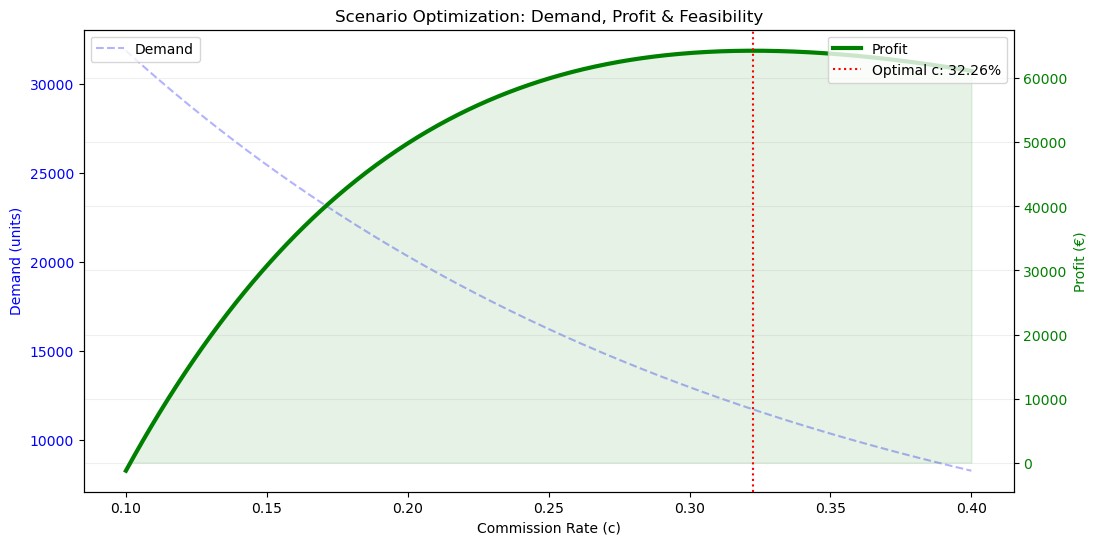

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Parameters
A = 50000        # Market potential
k = 4.5          # Price sensitivity
T_avg = 25       # Average order price
W = 1200         # Monthly cost per deliveryman
mu = 3           # Deliveries per hour per deliveryman
t_max = 0.5      # Max allowed wait time in hours (30 min)
H = 160          # Working hours per month

# Demand function
def demand_func(c):
    return A * np.exp(-k * c)

# Optimal n for a given c (minimum n that satisfies the waiting time constraint)
def get_optimal_n(c):
    D = demand_func(c)
    n_min_required = ((1/t_max) + (D/H)) / mu
    return np.clip(n_min_required, 10, 100) # Boundary constraint between 10 and 100

# Profit function
def profit_func(c):
    n = get_optimal_n(c)
    D = demand_func(c)
    revenue = D * T_avg * c
    costs = n * W + 0.1 * (n**2)
    return revenue - costs

# Optimization over commission c
res = minimize_scalar(lambda c: -profit_func(c), bounds=(0.1, 0.4), method='bounded')
opt_c = res.x
opt_n = get_optimal_n(opt_c)
opt_profit = -res.fun
opt_demand = demand_func(opt_c)
avg_wait_time = (1 / (mu * opt_n - opt_demand/H)) * 60 # In minutes

# Display results
print(f"--- ANALYTICAL RESULTS ---")
print(f"Optimal Commission: {opt_c:.4f} ({opt_c*100:.2f}%)")
print(f"Optimal nº of Deliverymen: {opt_n:.0f}")
print(f"Max Profit: {opt_profit:.2f} €")
print(f"Expected Monthly Demand: {opt_demand:.0f} units")
print(f"Average Waiting Time: {avg_wait_time:.2f} min")

# --- PLOTTING ---
c_range = np.linspace(0.1, 0.4, 500)
demands = [demand_func(c) for c in c_range]
profits = [profit_func(c) for c in c_range]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Demand
ax1.set_xlabel('Commission Rate (c)')
ax1.set_ylabel('Demand (units)', color='blue')
ax1.plot(c_range, demands, label="Demand", color='blue', alpha=0.3, linestyle='--')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot Profit
ax2 = ax1.twinx()
ax2.set_ylabel('Profit (€)', color='green')
# Clean profit for plotting (remove the penalty values)
profits_plot = [p if p > -100000 else None for p in profits]
ax2.plot(c_range, profits_plot, label="Profit", color='green', linewidth=3)
ax2.tick_params(axis='y', labelcolor='green')

# Visual Cues
ax2.axvline(opt_c, color='red', linestyle=':', label=f'Optimal c: {opt_c*100:.2f}%')
ax2.fill_between(c_range, profits_plot, 0, where=(np.array(profits_plot) > 0), color='green', alpha=0.1)

plt.title("Scenario Optimization: Demand, Profit & Feasibility")
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

#### Solve the problem numerically with pyomo

In [3]:
from pyomo.environ import *

# Parameters
A = 50000        # Market potential
k = 4.5          # Price sensitivity
T_avg = 25       # Average order price
W = 1200         # Monthly cost per deliveryman
mu = 3           # Deliveries per hour per deliveryman
t_max = 0.5      # Max allowed wait time in hours (30 min)
H = 160          # Working hours per month

# Create Pyomo model
model = ConcreteModel()

# Decision variables
model.c = Var(bounds=(0.10, 0.40), initialize=0.2)
model.n = Var(bounds=(10, 100), initialize=50)

# Demand and Profit functions
def demand_rule(m):
    return A * exp(-k * m.c)

def profit_rule(m):
    revenue = demand_rule(m) * T_avg * m.c
    costs = m.n * W + 0.1 * m.n**2
    return revenue - costs

model.profit = Objective(rule=profit_rule, sense=maximize)

# Non-linear Waiting Time Constraint
# We rearrange to avoid division by zero
def wait_time_rule(m):
    return (mu * m.n - demand_rule(m)/H) >= (1/t_max)

model.wait_con = Constraint(rule=wait_time_rule)

# Solve the model
solver = SolverFactory('ipopt')
solver.solve(model)

# Extract and calculate results
opt_c = value(model.c)
opt_n = value(model.n)
max_profit = value(model.profit)
exp_demand = value(demand_rule(model))
avg_wait_time = (1 / (mu * opt_n - exp_demand/H)) * 60

# Display results
print(f"--- PYOMO NUMERICAL RESULTS ---")
print(f"Optimal Commission: {opt_c:.4f}")
print(f"Optimal nº of Deliverymen: {opt_n:.0f}")
print(f"Max Profit: {max_profit:.2f} €")
print(f"Expected Monthly Demand: {exp_demand:.0f} units")
print(f"Average Waiting Time: {avg_wait_time:.2f} min")

--- PYOMO NUMERICAL RESULTS ---
Optimal Commission: 0.3226
Optimal nº of Deliverymen: 25
Max Profit: 64295.52 €
Expected Monthly Demand: 11706 units
Average Waiting Time: 30.00 min


### Result Analysis

Reviewing and analyzing the analytical results represented in the graph and the information displayed in the Pyomo version, we can verify that both answers are nearly identical. This consistency validates the mathematical robustness of the problem. Below is a deeper analysis of the meaning of these solutions:

The first insight is that the average waiting time is exactly **30 minutes**, which is the maximum limit we established. This indicates that the solver prioritized hiring fewer delivery agents to minimize labor costs. Without the maximum waiting time constraint, the solver would likely have chosen a longer wait time, as the platform is currently operating at its maximum capacity.

- The **optimal commission rate of 32.26%** provides significant insights. The demand function follows an exponential decay, while the revenue is defined as $R(c) = D(c) \cdot T_{avg} \cdot c$. Mathematically, the function $c \cdot e^{-kc}$ reaches its unconstrained peak at $c = 1/k$. Given our parameter $k = 4.5$, this peak would be at $1/4.5 = 0.2222$ (22.22%). However, our result of 32.26% is significantly higher. At this scale, the operational and management costs are so high that the solver prefers the platform to prioritize **quality (margins) over quantity (volume)**. By raising the commission, the platform:
    - Increases the profit earned per delivery.
    - Suppresses demand just enough so that only 25 delivery agents are required.
    If the commission were lower, demand would increase, forcing the platform to hire additional staff, which would ultimately decrease total profit due to the quadratic growth of management costs.

- The **optimal fleet size of 25 agents** is at the lower end of the range we established (10 to 100). With $n = 25$ and $\mu = 3$, the total capacity is 75 deliveries per hour. The expected monthly demand is 11,706 orders over 160 working hours, which is approximately 73.16 deliveries per hour.
$$\text{Utilization} = \frac{\text{Demand per hour}}{\text{Capacity per hour}} = \frac{73.16}{75} \approx 97.55\%$$
Operating at nearly 97.6% utilization explains why the waiting time is exactly 30 minutes; the system is pushed to its functional limit to remain efficient.

#### Final Conclusion
Based on the results:
- The platform is highly profitable, netting more than 64,000 € per month.
- The platform demonstrates significant pricing power, using a 32.26% commission to offset the high costs of a large-scale operation in a major city.
- The business is currently limited not by market demand, but by its own delivery capacity. To increase profit without raising prices, the platform should focus on increasing operational efficiency ($\mu$) rather than simply hiring more staff.